# Bennett dataset
> Ron S. Kenett, Chris Gotwalt, Laura Freeman, Peter Gedeck and Xinwei Deng


https://www.itl.nist.gov/div898/software/dataplot/data/BENNET11.DAT

In [2]:
import common
import metrics

In [3]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

Design of Experiment/2k Full Factorial
```
This is Dataplot data file     BENNET11.DAT
Trish Bennett Dental Adhesive Strength
May 1994
Unbalanced 2**5
Number of observations = 80
Number of variables per line image = 8
Order of variables on a line image--
   1. Y = Response Variable = Adhesive Shear Strength
   2. Factor 1 = Operator    (2 levels: S & A)
   3. Factor 2 = Day         (2 levels: 1 & 2)
   4. Factor 3 = Technique   (2 levels: regular & taped)
   5. Factor 4 = Wet/dry     (2 levels: damp & dry)
   6. Factor 5 = Company     (2 levels: X and Z)
   7. Factor 6 = Replication (6 levels: 1 to 6)
   8. Factor 7 = 2**3 Tech x W-d x System treatment (8 levels)
   9. Factor 8 = app.?
Note--a given operator has 6 replicates of a 2**3
Note--Operator 1 did not have balance over day
Note--Operator 2 had missing data
To read this into Dataplot--
   SKIP 25
   READ BENNET11.DAT Y X1 X2 X3 X4 X5 REP TREATMENT
```
The design is X3 x X4 x X5
Replication is created by operator and day 

In [4]:
data = pd.read_csv('Bennett.csv')
for col in range(1, 6):
    data[f'X{col}'] = (2 * (data[f'X{col}'] - 1.5)).astype(int)
data = data.rename(columns={'TREATMENT': 'group'})
data = data.rename(columns={f'X{n}': f'x{n}' for n in range(1, 6)})
data

,Y,x1,x2,x3,x4,x5,REP,group,N,Unknown
0,40.60,-1,-1,-1,-1,-1,1,1,1,152
1,42.19,-1,-1,-1,-1,-1,2,1,14,151
2,19.71,-1,-1,-1,-1,-1,3,1,23,165
3,27.64,-1,-1,-1,-1,-1,4,1,30,127
4,24.16,-1,1,-1,-1,-1,5,1,38,96
...,...,...,...,...,...,...,...,...,...,...
75,4.43,1,-1,1,1,1,2,8,11,61
76,9.22,1,-1,1,1,1,3,8,17,125
77,21.08,1,1,1,1,1,4,8,24,149
78,15.48,1,1,1,1,1,5,8,27,107


In [30]:
# Replications
print(data['group'].value_counts(sort=False))
print()

print(data[['x1', 'x2', 'x3', 'x4', 'x5']].value_counts(sort=False))

# Imbalance
print(f'L1-imbalance: {metrics.L1_distance(data['group'].value_counts())}')


group
1    12
2    11
3     5
4    11
5    12
6    12
7     5
8    12
Name: count, dtype: int64

x1  x2  x3  x4  x5
-1  -1  -1  -1  -1    4
                 1    4
             1  -1    3
                 1    3
         1  -1  -1    4
                 1    4
             1  -1    3
                 1    4
     1  -1  -1  -1    2
                 1    2
             1  -1    2
                 1    2
         1  -1  -1    1
                 1    2
             1  -1    2
                 1    2
 1  -1  -1  -1  -1    3
                 1    3
         1  -1  -1    3
                 1    3
             1  -1    3
                 1    3
     1  -1  -1  -1    3
                 1    3
         1  -1  -1    3
                 1    3
             1  -1    3
                 1    3
Name: count, dtype: int64
L1-imbalance: 2.0


In [6]:
data[['x1', 'x2']].value_counts(sort=False)

x1  x2
-1  -1    29
     1    15
 1  -1    18
     1    18
Name: count, dtype: int64

# Set random seed for reproducibility
In order to reproduce the results from the publication, the random seeds must be set to 123.

In [7]:
random.seed(123)
np.random.seed(123)

# Build a variety of models using main effects and interactions

In [8]:
main_terms = 'x1 + x2 + x3 + x4 + x5'

main_formula = f'Y ~ {main_terms}'
group = 'group'

In [9]:
common.buildModel(data, main_formula).conf_int(alpha = .05)

,0,1
Intercept,16.153412,19.792711
x1,-8.068237,-4.445274
x2,-1.829589,1.715793
x3,-2.577834,1.058106
x4,-5.414724,-1.775501
x5,-0.410626,3.031878


In [10]:
def olsAnalysis(data, formula):
    model = common.buildModel(data, formula)
    return {'coef': model.params, 'std': model.bse, 'conf_int': model.conf_int(alpha=.05)}

nrepeats = 1000
results_BA = common.bootstrapAnalysis(data, main_formula, nrepeats=nrepeats)
results_BBA = common.befittingBootstrapAnalysis(data, main_formula, ['group'], nrepeats=nrepeats)
results_wBA = common.wildBootstrapAnalysis(data, main_formula, nrepeats=nrepeats)
results_OLS = olsAnalysis(data, main_formula)



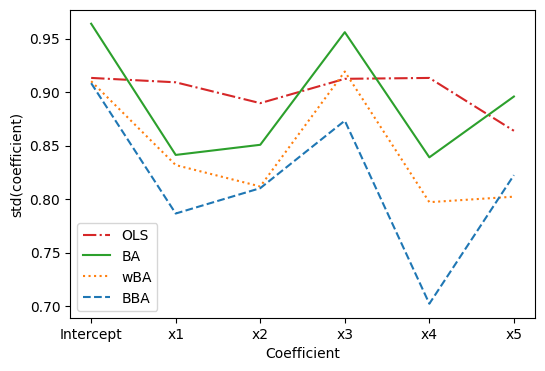

In [29]:
order = ['OLS', 'BA', 'wBA', 'BBA']
colors = {
    'BBA': 'C0',
    'wBA': 'C1',
    'BA': 'C2',
    'OLS': 'C3',
}
linestyles = {
    'BBA': '--',
    'wBA': ':',
    'BA': '-',
    'OLS': '-.',
}


std_results = {
    'BBA': results_BBA.std(),
    'wBA': results_wBA.std(),
    'BA': results_BA.std(),
    'OLS': results_OLS['std'],
}
std_results = pd.DataFrame(std_results)
fig, ax = plt.subplots(figsize=(6, 4))

for method in order:
    std_results[method].plot(
        color=colors[method],
        linestyle=linestyles[method],
        label=method,
        ax=ax,
    )
ax.legend()
legend = ax.get_legend()
for i, method in enumerate(order):
    legend.get_lines()[i].set_color(colors[method])

# ax = std_results.plot()
ax.set_ylabel('std(coefficient)')
ax.set_xlabel('Coefficient')
plt.show()

# OLS Residuals analysis

In [12]:
residuals = data.copy()
residuals['residuals'] = common.buildModel(data, main_formula).resid

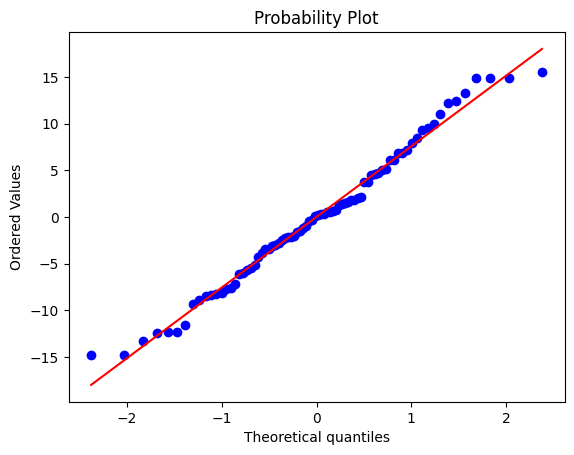

In [13]:
fig, ax = plt.subplots()
_ = stats.probplot(residuals['residuals'], dist="norm", plot=ax)


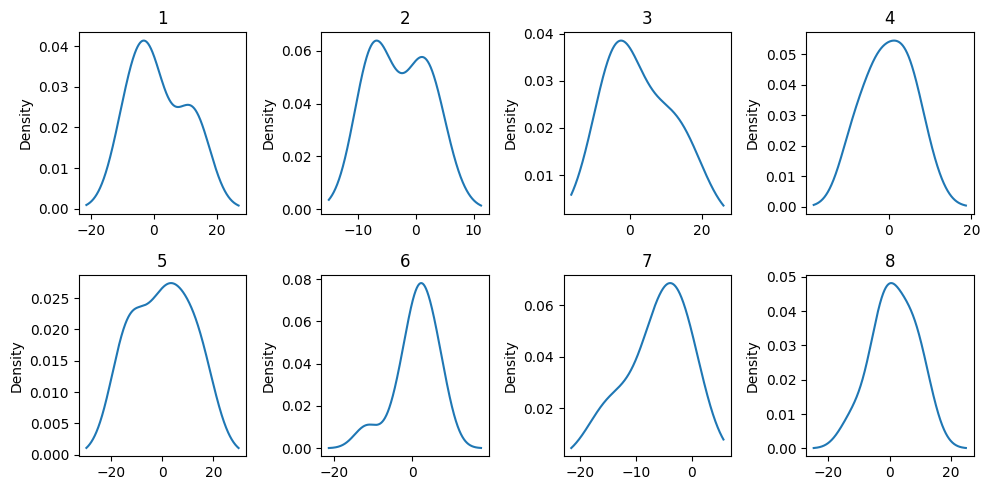

In [14]:
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(10, 5))
axes = axes.flatten()
for group, ax in zip(residuals['group'].unique(), axes):
    residuals[residuals['group'] == group]['residuals'].plot.density(ax=ax)
    ax.set_title(group)
    # ax.set_xlim(-3, 3)
    # ax.set_ylim(-3, 3)
plt.tight_layout()

Residuals in groups are not all normally distributed. 

/Users/petergedeck/cdd/bba-case-study/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)
/Users/petergedeck/cdd/bba-case-study/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)
/var/folders/_8/ms0ft4913k3290v7f0g_yfpc0000gn/T/ipykernel_16435/3142363024.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(stats.normaltest(residuals[residuals['group'] == group]['residuals']))


NormaltestResult(statistic=np.float64(2.347643063688329), pvalue=np.float64(0.3091831275476844))
NormaltestResult(statistic=np.float64(3.782308017571995), pvalue=np.float64(0.1508975711968771))
NormaltestResult(statistic=np.float64(nan), pvalue=np.float64(nan))
NormaltestResult(statistic=np.float64(0.3742599164071094), pvalue=np.float64(0.8293359503714636))
NormaltestResult(statistic=np.float64(2.416755766086666), pvalue=np.float64(0.2986813828232939))
NormaltestResult(statistic=np.float64(7.070880200203105), pvalue=np.float64(0.029145927040922923))
NormaltestResult(statistic=np.float64(nan), pvalue=np.float64(nan))
NormaltestResult(statistic=np.float64(0.25300010046722815), pvalue=np.float64(0.8811741052789545))


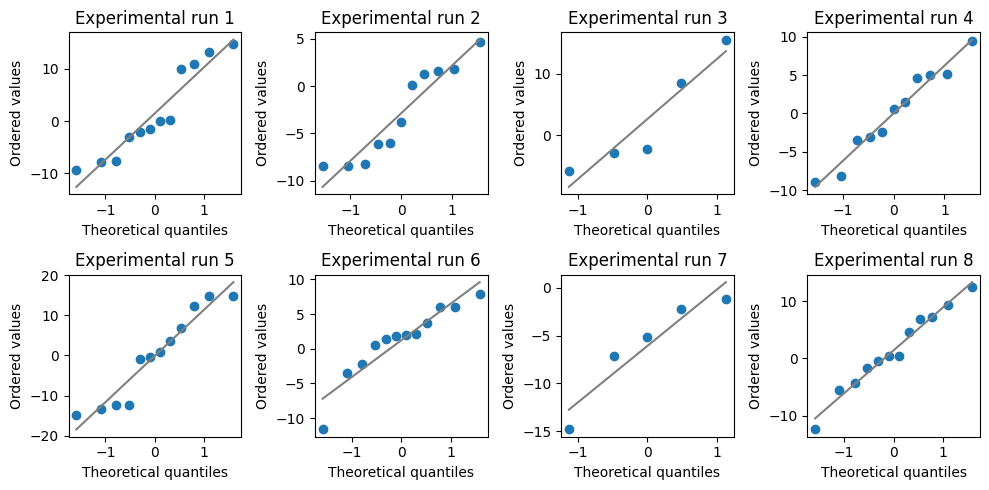

In [37]:
fig, axes = plt.subplots(ncols=4, nrows=2, figsize=(10, 5))
axes = axes.flatten()
for group, ax in zip(residuals['group'].unique(), axes):
    print(stats.normaltest(residuals[residuals['group'] == group]['residuals']))
    stats.probplot(residuals[residuals['group'] == group]['residuals'], dist="norm", plot=ax)
    ax.set_title(f'Experimental run {group}')
    ax.set_ylabel('Ordered values')
    ax.get_lines()[0].set_markerfacecolor('C0')
    ax.get_lines()[0].set_markeredgecolor('C0')
    ax.get_lines()[1].set_color('grey')
plt.tight_layout()

# Confidence intervals for coefficients

In [16]:
results_OLS


{'coef': Intercept    17.973062
 x1           -6.256755
 x2           -0.056898
 x3           -0.759864
 x4           -3.595112
 x5            1.310626
 dtype: float64,
 'std': Intercept    0.913230
 x1           0.909130
 x2           0.889663
 x3           0.912387
 x4           0.913210
 x5           0.863847
 dtype: float64,
 'conf_int':                    0          1
 Intercept  16.153412  19.792711
 x1         -8.068237  -4.445274
 x2         -1.829589   1.715793
 x3         -2.577834   1.058106
 x4         -5.414724  -1.775501
 x5         -0.410626   3.031878}

In [17]:
def getConfidenceIntervals(results, method):
    confint = pd.DataFrame()
    # for key in results:
    #     a = results[key]
    #     confint[key] = sms.DescrStatsW(a).tconfint_mean()
    # confint = confint.transpose()
    # confint.columns = ['lower', 'upper']
    confint['lower'] = results.quantile(0.025)
    confint['upper'] = results.quantile(0.975)
    confint['mean'] = results.mean()
    confint['std'] = results.std()
    confint['method'] = method
    confint['coefficient'] = confint.index
    return confint

def getConfidenceIntervalsOLS(results, method):
    confint = pd.DataFrame()
    confint['lower'] = results['conf_int'][0]
    confint['upper'] = results['conf_int'][1]
    confint['mean'] = results['coef']
    confint['std'] = results['std']
    confint['method'] = method
    confint['coefficient'] = confint.index
    return confint

coef_results = pd.concat([
    getConfidenceIntervals(results_BA, 'BA'),
    getConfidenceIntervals(results_BBA, 'BBA'),
    getConfidenceIntervals(results_wBA, 'wBA'),
    getConfidenceIntervalsOLS(results_OLS, 'OLS'),
])
coef_results

,lower,upper,mean,std,method,coefficient
Intercept,16.152769,19.991626,18.004052,0.963845,BA,Intercept
x1,-7.876103,-4.658254,-6.262554,0.841309,BA,x1
x2,-1.718943,1.515352,-0.076477,0.850771,BA,x2
x3,-2.639352,1.082189,-0.813335,0.955936,BA,x3
x4,-5.243399,-1.878971,-3.608544,0.839061,BA,x4
x5,-0.467292,3.028599,1.339940,0.895849,BA,x5
Intercept,16.309650,19.865423,18.008359,0.908326,BBA,Intercept
x1,-7.695036,-4.724986,-6.240709,0.786583,BBA,x1
x2,-1.634444,1.519977,-0.080723,0.810253,BBA,x2
x3,-2.560840,0.846864,-0.828270,0.873269,BBA,x3


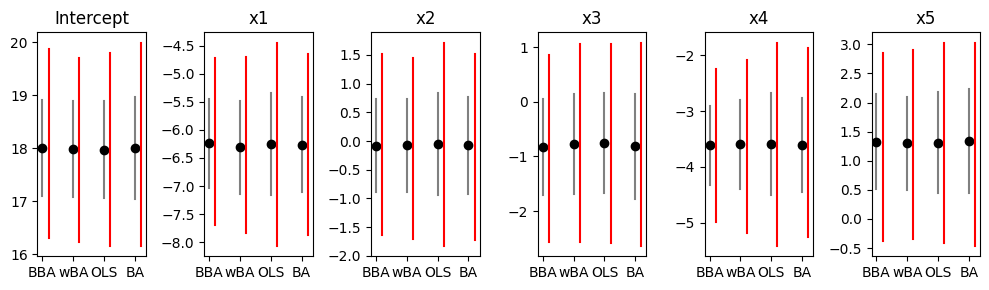

In [18]:
order = ['BA', 'OLS', 'wBA', 'BBA']
term = 'x1'

def plotTerm(term, ax):
    revorder = list(reversed(order))
    for n, method in enumerate(revorder, 1):
        subset = coef_results[coef_results['coefficient'] == term]
        subset = subset[subset['method'] == method]
        ax.plot([n, n], [subset['mean'] - subset['std'], subset['mean'] + subset['std']], color='grey')
        ax.plot(n, subset['mean'], 'o', color='black')
        ax.plot([n+0.2, n+0.2], [subset['lower'], subset['upper']], color='red')
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(revorder)

fig, axes = plt.subplots(ncols=6, nrows=1, figsize=(10, 3))
axes = axes.flatten()
for term, ax in zip(coef_results['coefficient'].unique(), axes):
    plotTerm(term, ax)
    ax.set_title(term)
plt.tight_layout()